# Variant Analysis

Understand the behavior hidden inside an XES log before attempting subprocess discovery.

1. How many traces are there?
2. How many activities?
3. How many variants?
4. What are the most common variants?
5. How much behavioral diversity exists?
6. Are there candidate regions that might later become subprocesses?

In [1]:
import pm4py 
import pandas as pd 
from collections import Counter
from pm4py.objects.conversion.log import converter as log_converter


## Load Event Log
Read the repair example XES file and convert it to a PM4Py event log object.

In [ ]:
LOG_PATH = "../../data/villach/processflow_export.xes" 
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH) )

c:\Users\safaya\Documents\GitHub\process-fragment-miner\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

## Basic Statistics
Count the number of traces and unique activities to get an overview of the log.

In [3]:
num_traces = len(event_log) 
activities = set() 
for trace in event_log:
    for event in trace: 
        activities.add(event["concept:name"])
print("Traces:", num_traces) 
print("Unique activities:", len(activities)) 
print("Activities:") 
print(sorted(activities))

Traces: 53
Unique activities: 25
Activities:
['1017', '1027', '1028', '1029', '1033', '1035', '2085', '2095', '2200', '2205', '2210', '2230', '2250', '2255', '2295', '7777', '9020', '9030', '9050', '9390', '9450', '9841', '9922', '9924', '9996']


## Inspect First Trace
Look at the sequence of activities in the first trace to understand the data format.

In [4]:
# Inspect First Trace
first_trace = event_log[0] 
print("Case ID:", first_trace.attributes["concept:name"]) 
for event in first_trace: 
    print(event["concept:name"])

Case ID: 12276866
1017
1028
1029
1033
1035
2200
2230
2250
9020
9030
9050
9841
9922
9924
9996


## Extract Activity Sequences
Convert every trace into a list of activity names for easier analysis.

In [5]:
# Convert Log to Activity Sequences
activity_sequences = []
for trace in event_log:
    sequence = [event["concept:name"] for event in trace]
    activity_sequences.append(sequence)

print(activity_sequences[0])  # Print first sequence

['1017', '1028', '1029', '1033', '1035', '2200', '2230', '2250', '9020', '9030', '9050', '9841', '9922', '9924', '9996']


## Count Unique Variants
A variant is a unique sequence of activities. Count how many distinct variants exist in the log.

In [6]:
# Compute Variants
variant_counts = Counter(tuple(seq) for seq in activity_sequences)
print(f"Number of unique variants: {len(variant_counts)}")


Number of unique variants: 11


## Top 10 Variants
Print the 10 most frequent variants with their activity sequences and case counts.

In [7]:
# Top 10 Variants
top_variants = variant_counts.most_common(10)
for i, (variant, freq) in enumerate(top_variants, start=1):
    print("=" * 80)
    print(f"Variant {i}")
    print(f"Frequency: {freq}")
    for activity in variant:
        print(" ", activity)

Variant 1
Frequency: 12
  1017
  1028
  1029
  1033
  1035
  2200
  2230
  2250
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 2
Frequency: 10
  1017
  1028
  1029
  1033
  1035
  2205
  2230
  2250
  2255
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 3
Frequency: 9
  1017
  1027
  2085
  2095
  2200
  2230
  2250
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 4
Frequency: 7
  1017
  1027
  2085
  2095
  2200
  2230
  2250
  7777
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 5
Frequency: 5
  1017
  1028
  1029
  1033
  1035
  2205
  2230
  2250
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 6
Frequency: 3
  1017
  1028
  1029
  1033
  1035
  2200
  2230
  2250
  2255
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 7
Frequency: 2
  1017
  1028
  1029
  1033
  1035
  2210
  2230
  2250
  2255
  9020
  9030
  9050
  9841
  9922
  9924
  9996
Variant 8
Frequency: 2
  1017
  1028
  1029
  1033
  1035
  2210
  2230
  2250
  2255
  

## Variant Coverage
How much of the log do the top variants explain? Cumulative coverage reveals behavioral concentration.

In [8]:
# Variant Coverage
total_cases = len(event_log)
running = 0
for i, (_, freq) in enumerate(top_variants, start=1):
    running += freq
    coverage = running / total_cases
    print(f"Top {i} variants cover {coverage:.2%} of cases")

Top 1 variants cover 22.64% of cases
Top 2 variants cover 41.51% of cases
Top 3 variants cover 58.49% of cases
Top 4 variants cover 71.70% of cases
Top 5 variants cover 81.13% of cases
Top 6 variants cover 86.79% of cases
Top 7 variants cover 90.57% of cases
Top 8 variants cover 94.34% of cases
Top 9 variants cover 96.23% of cases
Top 10 variants cover 98.11% of cases


## Trace Length Distribution
Analyze how long each trace is (in number of events) to understand process complexity.

In [9]:
# Trace Length Distribution
trace_lengths = [
    len(trace)
    for trace in event_log
]

print("Min length:", min(trace_lengths))
print("Max length:", max(trace_lengths))
print("Average length:", sum(trace_lengths)/len(trace_lengths))

Min length: 14
Max length: 19
Average length: 15.377358490566039


## Activity Frequency
Count how many times each activity appears across the entire log.

In [10]:
# Most Frequent Activities
activity_freq = Counter(event["concept:name"] for trace in event_log for event in trace)
print("Most common activities:")
for activity, freq in activity_freq.most_common(10):
    print(f"  {activity}: {freq} occurrences")

Most common activities:
  1017: 53 occurrences
  2230: 53 occurrences
  2250: 53 occurrences
  9020: 53 occurrences
  9030: 53 occurrences
  9050: 53 occurrences
  9841: 53 occurrences
  9922: 53 occurrences
  9924: 53 occurrences
  9996: 53 occurrences


## Directly-Follows Graph
Count how often each activity is directly followed by another. This reveals branching and sequential patterns.

In [11]:
# Directly-Follows Relationships. This immediately reveals branching.
dfg_counter = Counter() 
for trace in activity_sequences: 
    for i in range(len(trace)-1): 
        pair = ( trace[i], trace[i+1] ) 
        dfg_counter[pair] += 1 
for edge, freq in dfg_counter.most_common(20): 
    print(edge, freq)

('2230', '2250') 53
('9020', '9030') 53
('9030', '9050') 53
('9841', '9922') 53
('9922', '9924') 53
('9924', '9996') 53
('9050', '9841') 49
('1017', '1028') 37
('1028', '1029') 37
('1029', '1033') 37
('1033', '1035') 37
('2200', '2230') 31
('2250', '9020') 27
('2250', '2255') 19
('2255', '9020') 17
('1017', '1027') 16
('1027', '2085') 16
('2085', '2095') 16
('2095', '2200') 16
('1035', '2205') 16


## Variation Points
Identify activities that can be followed by multiple different activities — these are decision points in the process.

In [12]:
# Identify Candidate Variation Points
successors = {} 
for trace in activity_sequences: 
    for i in range(len(trace)-1): 
        current = trace[i] 
        nxt = trace[i+1] 
        successors.setdefault( current, set() ).add(nxt) 
for activity, next_activities in successors.items(): 
    if len(next_activities) > 1: 
        print(activity) 
        print(" ->", next_activities)

1017
 -> {'1027', '1028'}
1035
 -> {'2200', '2210', '2205'}
2250
 -> {'7777', '9020', '2255'}
9050
 -> {'9390', '9841'}
2255
 -> {'9020', '2295'}


## Visualize DFG with PM4Py
Render the full directly-follows graph with frequency annotations.

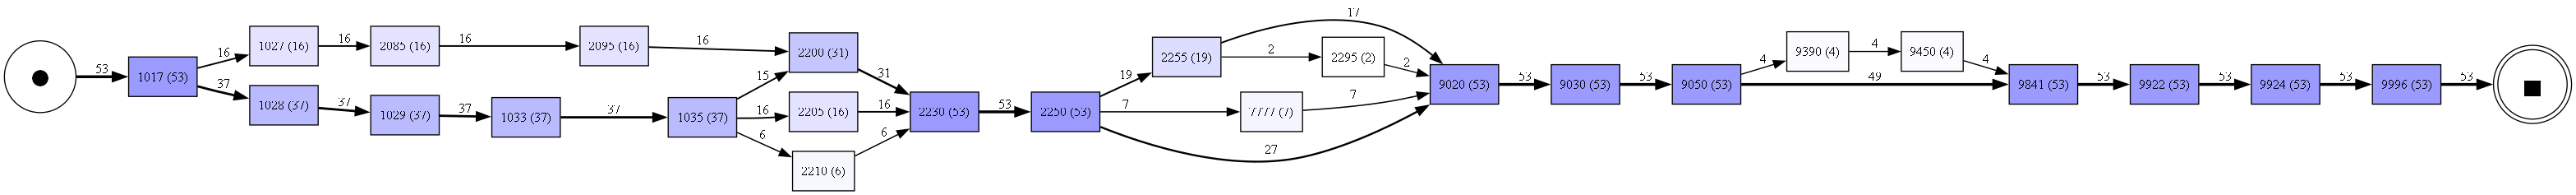

In [13]:
from pm4py.visualization.dfg import visualizer as dfg_visualizer

dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)

gviz = dfg_visualizer.apply(
    dfg,
    variant=dfg_visualizer.Variants.FREQUENCY,
    parameters={
        dfg_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png",
        "start_activities": start_activities,
        "end_activities": end_activities,
    },
)
dfg_visualizer.view(gviz)